In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import sys
sys.path.append("..")
from CEStools.utils import clean_data

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ModuleNotFoundError: No module named 'sklearn'

In [2]:
# Import and clean the data
df_raw = pd.read_csv('data/calenviroscreen40.csv')

df_clean = clean_data(df_raw)
X = df_clean[df_clean.notna().all(axis=1)]

- CalEnviroScreen uses `-999` and `-1998` as *sentinel values* meaning “missing” or “not applicable”.  
- We create a boolean mask that keeps only rows where **all** entries do not include `-999` and `-1998`.  
- The cleaned DataFrame is stored in `X`.  
- We print the number of original vs. cleaned rows to see how many tracts were removed.

In [3]:
print(f"Original rows: {len(df_clean):,}")
print(f"Clean rows   : {len(X):,}")

Original rows: 8,035
Clean rows   : 7,354


In [4]:
X

,CIscoreP,OzoneP,PM2_5_P,DieselPM_P,PesticideP,Tox_Rel_P,TrafficP,DrinkWatP,Lead_P,CleanupP,...,PovertyP,UnemplP,HousBurdP,PopCharP,Hispanic,White,AfricanAm,NativeAm,OtherMult,AAPI
0,69.162885,10.566273,10.031114,52.408214,92.034483,9.914979,63.4000,11.165230,36.118463,17.077268,...,89.660804,18.310776,69.150824,79.828543,68.9210,20.8899,0.4004,0.2670,1.3126,8.2091
1,70.637922,11.561917,10.454263,39.365277,99.586207,10.265066,19.9000,52.828775,43.805923,72.396417,...,83.040201,69.130661,60.101394,56.555724,78.6229,13.2240,2.5051,0.0000,0.9489,4.6990
2,61.069087,10.566273,9.931549,60.311139,93.827586,10.515129,42.7500,11.165230,75.072464,2.071669,...,52.876884,35.020822,53.624842,67.183560,65.7214,30.6088,0.9591,0.0000,2.1685,0.5421
3,5.988401,13.615432,10.653391,34.275047,95.413793,7.864466,39.9250,32.559011,11.077505,0.000000,...,7.550251,58.355023,16.311787,10.741301,22.9537,69.1948,0.9342,0.7117,2.5356,3.6699
4,23.121533,13.615432,10.690728,18.481643,63.241379,7.714429,24.3625,32.559011,49.514808,2.071669,...,35.150754,92.399792,12.002535,46.280888,33.4082,59.7804,0.6986,1.4721,1.3723,3.2685
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8030,30.610187,88.699440,72.109521,12.433105,0.000000,69.217304,18.7625,66.866492,80.340265,19.914147,...,31.733668,1.900052,40.899873,22.339889,28.7132,53.3995,1.5733,0.0000,7.1549,9.1590
8031,22.566818,79.987554,70.242688,21.306783,0.000000,70.430108,57.9875,73.148495,52.715816,5.636432,...,41.030151,30.882353,52.610900,16.502774,10.9507,26.3918,3.3677,0.0000,3.3677,55.9221
8032,74.508321,84.579963,72.906036,90.914748,0.000000,74.356089,79.2625,60.334707,57.996219,94.438223,...,57.298995,59.383134,29.721166,43.582955,58.2273,16.1438,8.9967,0.0000,1.1098,15.5223
8033,97.049924,46.994400,79.452396,42.265090,0.000000,91.047762,62.4000,71.362558,94.820416,74.300112,...,91.557789,82.326913,64.461343,92.939990,91.4114,6.9425,0.6728,0.2577,0.7157,0.0000


- K-means is distance-based, so features with larger scales can dominate the distance computation.  
- We use `StandardScaler` to transform each feature to have:
  - mean ≈ 0  
  - standard deviation ≈ 1  

- The scaled feature matrix is stored in `X_scaled`.  
- For each `k` from 2 to 10:
  - Fit a `KMeans` model on `X_scaled` with:
    - `random_state=42` for reproducibility  
    - `n_init=10` to run the algorithm multiple times and keep the best solution.
  - Store the **inertia** (within-cluster sum of squared distances) in `inertias`.
  - Compute the **silhouette score** (how well-separated the clusters are) and store it in `sil_scores`.

In [5]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)

In [6]:
# Run KMeans for k = 2,...,10 and compute inertia + silhouette score
k_values = list(range(2, 11))
inertias = []
sil_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,  # set random state for reproducibility
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

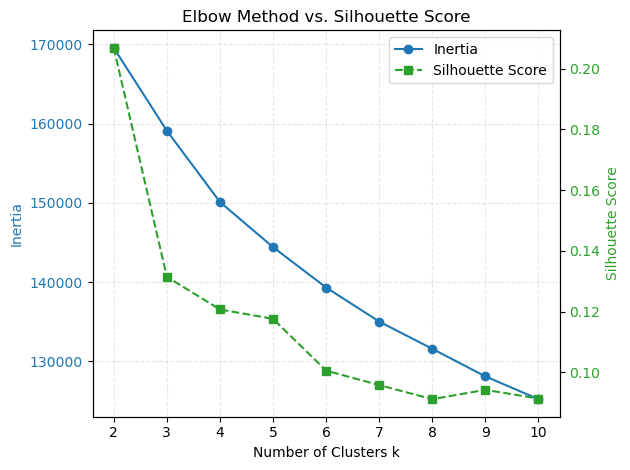

In [7]:
# Plot: Elbow (Inertia) + Silhouette on twin axes
fig, ax1 = plt.subplots()

# Inertia line (left y-axis)
ax1.plot(
    k_values, inertias,
    marker="o",
    color="tab:blue",
    label="Inertia"
)
ax1.set_xlabel("Number of Clusters k")
ax1.set_ylabel("Inertia", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_title("Elbow Method vs. Silhouette Score")
ax1.grid(alpha=0.3, linestyle="--")  # light grid

# Silhouette line (right y-axis)
ax2 = ax1.twinx()
ax2.plot(
    k_values, sil_scores,
    marker="s",
    linestyle="--",
    color="tab:green",
    label="Silhouette Score"
)
ax2.set_ylabel("Silhouette Score", color="tab:green")
ax2.tick_params(axis="y", labelcolor="tab:green")

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.tight_layout()
plt.savefig("visualizations/kmeans_visualizations/elbowvssilohuette_chart.png", dpi=300, bbox_inches="tight")

plt.show()


## Interpretation: Elbow & Silhouette Plot

- The **inertia curve** (blue) decreases as we increase `k`, with diminishing returns after a certain point.  
- The **silhouette curve** (green) shows how well-separated the clusters are for each `k`.  
- We choose the value of `k` with the highest silhouette score (here, `k = 2`), balancing model fit and cluster separation.


In [8]:
feature_cols = ['CIscoreP', 'OzoneP',  'PM2_5_P', 'DieselPM_P', 'PesticideP',
                 'Tox_Rel_P', 'TrafficP', 'DrinkWatP', 'Lead_P', 'CleanupP',
                 'GWThreatP', 'HazWasteP', 'ImpWatBodP', 'SolWasteP', 'PolBurdP',
                 'AsthmaP', 'LowBirWP', 'CardiovasP', 'EducatP', 'Ling_IsolP',
                 'PovertyP', 'UnemplP', 'HousBurdP', 'PopCharP', 
                'Hispanic', 'White', 'AfricanAm', 'NativeAm', 'OtherMult', 'AAPI']

# Fit final model with best k (=2) based on silhouette
best_k = k_values[sil_scores.index(max(sil_scores))]
print(f"\nBest k based on silhouette score: {best_k}")

final_kmeans_2 = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)
final_labels_2 = final_kmeans_2.fit_predict(X_scaled)

cluster_centers = pd.DataFrame(
    final_kmeans_2.cluster_centers_,
    columns=feature_cols
)

cluster_centers


Best k based on silhouette score: 2


,CIscoreP,OzoneP,PM2_5_P,DieselPM_P,PesticideP,Tox_Rel_P,TrafficP,DrinkWatP,Lead_P,CleanupP,...,PovertyP,UnemplP,HousBurdP,PopCharP,Hispanic,White,AfricanAm,NativeAm,OtherMult,AAPI
0,0.886505,0.231807,0.502308,0.355547,-0.033506,0.389607,0.123718,0.351488,0.656137,0.258066,...,0.763402,0.454328,0.603947,0.852096,0.786568,-0.760642,0.272985,-0.064769,-0.438613,-0.164873
1,-0.789853,-0.206534,-0.447543,-0.316783,0.029853,-0.347129,-0.110230,-0.313167,-0.584601,-0.229930,...,-0.680171,-0.404795,-0.538101,-0.759195,-0.700812,0.677713,-0.243223,0.057707,0.390793,0.146898


## Interpretation : Cluster centers for k=2 (standardized scale)

- **Cluster 0**: shows positive standardized scores across CalEnviroScreen percentiles for pollution burden (e.g., PM2.5, Diesel PM, Pollution Burden), health outcomes (AsthmaP, CardiovasP), and socioeconomic vulnerability (PovertyP, UnemplP, PopCharP), while having a strongly negative deviation for White population share. This cluster can be interpreted as high-burden, high-vulnerability, minority-majority communities.

- **Cluster 1**:  in contrast, exhibits negative standardized values for most environmental, health, and vulnerability indicators, and a positive deviation for White population share. This cluster corresponds to low-burden, more advantaged, White-majority communities.

- We select the value of `k` = 2  that gives the **maximum silhouette score**.

- Using this `best_k`, we fit a final `KMeans` model on `X_scaled`:
  - The final cluster assignments for each tract are stored in `final_labels`.
  - The standardized cluster means (centers) are stored in `cluster_centers` as a DataFrame.

- Each entry in `cluster_centers` is a **z-score**:
  - Positive values (> 0) mean the cluster has above-average levels for that feature.
  - Negative values (< 0) mean below-average levels for that feature.

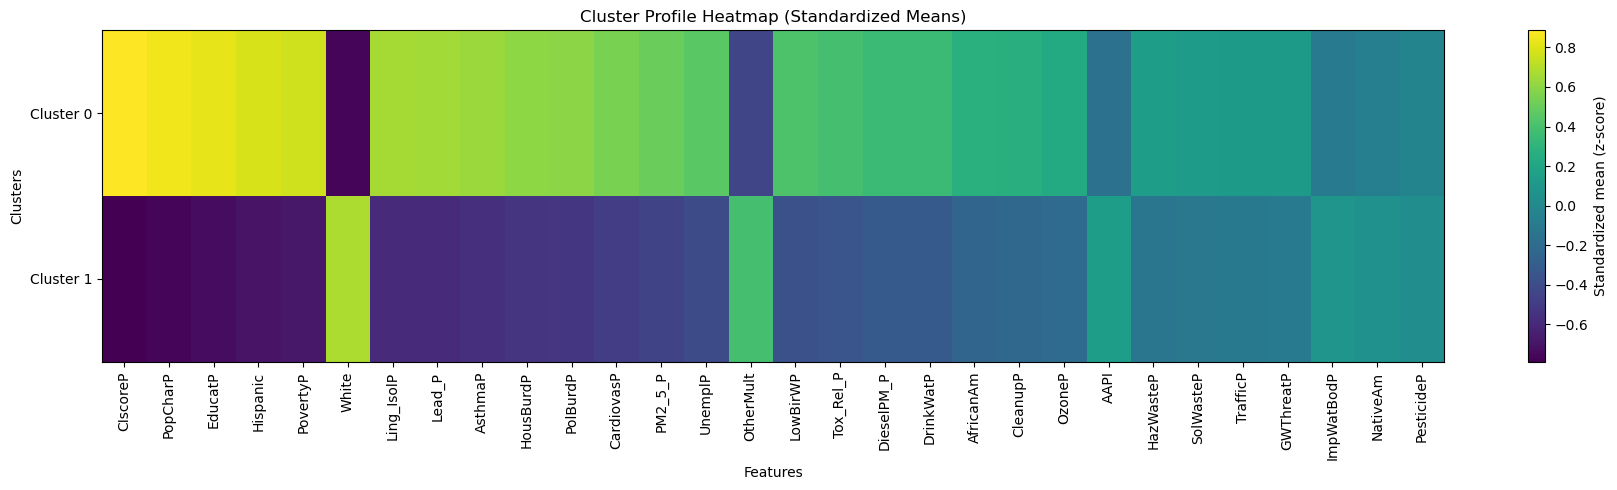

In [9]:
# 1) Convert cluster centers into a DataFrame
cluster_centers = pd.DataFrame(
    final_kmeans_2.cluster_centers_,
    columns=feature_cols
)

# 2) Sort features by how different they are across clusters
#    (sort by variance across cluster means, descending)
feature_order = cluster_centers.var(axis=0).sort_values(ascending=False).index
cluster_centers_ord = cluster_centers[feature_order]

# 3) Draw the heatmap

fig, ax = plt.subplots(figsize=(min(0.5 * len(feature_order) + 3, 18), 3 + best_k))

im = ax.imshow(cluster_centers_ord, aspect="auto")

# Set x and y tick labels

ax.set_xticks(range(len(feature_order)))
ax.set_xticklabels(feature_order, rotation=90)

ax.set_yticks(range(best_k))
ax.set_yticklabels([f"Cluster {i}" for i in range(best_k)])

ax.set_title("Cluster Profile Heatmap (Standardized Means)")
ax.set_xlabel("Features")
ax.set_ylabel("Clusters")

# Add colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Standardized mean (z-score)")

plt.tight_layout()
plt.savefig("visualizations/kmeans_visualizations/cluster_heatmap_2.png", dpi=300, bbox_inches="tight")

plt.show()


### Cluster profile heatmap (k=2)

The heatmap above shows the standardized cluster means (z-scores) for all CalEnviroScreen indicators and race-composition variables.

- Each row corresponds to one cluster (Cluster 0 and Cluster 1).
- Each column is a feature (e.g., CIscoreP, PolBurdP, PovertyP, PM2_5_P, White, etc.).
- Colors represent standardized means:
  - Yellow / light colors indicate **above-average** values (positive z-scores).
  - Purple / dark colors indicate **below-average** values (negative z-scores).

We see a very clear pattern:

- **Cluster 0** has high values for `CIscoreP`, `PolBurdP`, `PM2_5_P`, `DieselPM_P`, `AsthmaP`, `CardiovasP`, `PovertyP`, `UnemplP`, `PopCharP`, and other vulnerability metrics, while having a strongly negative value for White.  
  → This cluster represents **high-burden, high-vulnerability, minority-majority communities**.

- **Cluster 1** shows the opposite pattern: most environmental and socioeconomic burden indicators are below average, while `White` is above average.  
  → This cluster represents **low-burden, more advantaged, White-majority communities**.

Features near zero in both clusters (e.g., GWThreatP, ImpWatBodP, PesticideP) do not strongly differentiate between clusters.


In [10]:
final_kmeans_4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
final_labels_4 = final_kmeans_4.fit_predict(X_scaled)

cluster_centers = pd.DataFrame(
    final_kmeans_4.cluster_centers_,
    columns=feature_cols
)

cluster_centers

,CIscoreP,OzoneP,PM2_5_P,DieselPM_P,PesticideP,Tox_Rel_P,TrafficP,DrinkWatP,Lead_P,CleanupP,...,PovertyP,UnemplP,HousBurdP,PopCharP,Hispanic,White,AfricanAm,NativeAm,OtherMult,AAPI
0,0.163023,0.315260,-0.357524,-0.491246,0.451294,-0.599798,-0.559154,-0.033611,-0.084915,-0.327967,...,0.485245,0.513885,0.043427,0.563190,0.243830,-0.087735,0.168028,0.242361,0.036419,-0.377593
1,-1.195938,-0.229747,-0.604225,-0.678470,0.089290,-0.529550,-0.350217,-0.439827,-0.794830,-0.447555,...,-0.949510,-0.570933,-0.793418,-1.108066,-0.849991,1.039094,-0.384304,0.033895,0.377490,-0.108950
2,1.180867,0.304916,0.853813,0.572936,-0.195983,0.725536,0.277460,0.593590,0.966809,0.450978,...,0.957071,0.507591,0.836477,1.041357,1.113518,-0.992137,0.287438,-0.121336,-0.703313,-0.303633
3,-0.126892,-0.369961,0.028404,0.564096,-0.279100,0.307955,0.586114,-0.149492,-0.124495,0.290071,...,-0.442104,-0.385137,-0.088387,-0.424706,-0.525911,0.022339,-0.036511,-0.114567,0.348564,0.821319


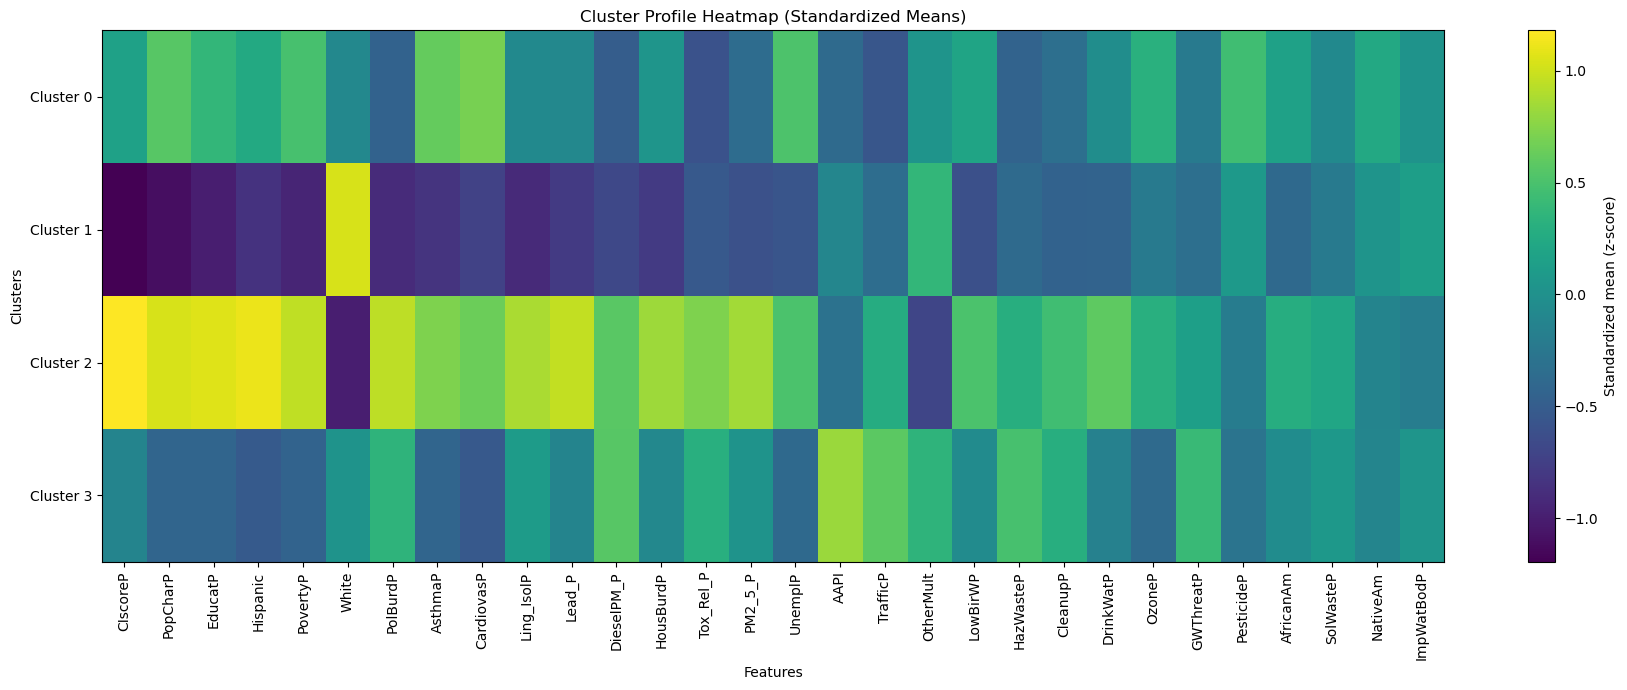

In [11]:
# 1) Convert cluster centers into a DataFrame
cluster_centers = pd.DataFrame(
    final_kmeans_4.cluster_centers_,
    columns=feature_cols
)

# 2) Sort features by how different they are across clusters
#    (sort by variance across cluster means, descending)
feature_order = cluster_centers.var(axis=0).sort_values(ascending=False).index
cluster_centers_ord = cluster_centers[feature_order]

# 3) Draw the heatmap

fig, ax = plt.subplots(figsize=(min(0.5 * len(feature_order) + 3, 18), 3 + 4))

im = ax.imshow(cluster_centers_ord, aspect="auto")

# Set x and y tick labels

ax.set_xticks(range(len(feature_order)))
ax.set_xticklabels(feature_order, rotation=90)

ax.set_yticks(range(4))
ax.set_yticklabels([f"Cluster {i}" for i in range(4)])

ax.set_title("Cluster Profile Heatmap (Standardized Means)")
ax.set_xlabel("Features")
ax.set_ylabel("Clusters")

# Add colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Standardized mean (z-score)")

plt.tight_layout()
plt.savefig("visualizations/kmeans_visualizations/cluster_heatmap_4.png", dpi=300, bbox_inches="tight")

plt.show()


### Cluster profile heatmap (k=4)

The heatmap above shows the standardized cluster means (z-scores) for all CalEnviroScreen indicators and race-composition variables.

- Each row corresponds to one cluster (Clusters 0,  1, 2, and 3).
- Each column is a feature (e.g., CIscoreP, PolBurdP, PovertyP, PM2_5_P, White, etc.).
- Colors represent standardized means:
  - Yellow / light colors indicate **above-average** values (positive z-scores).
  - Purple / dark colors indicate **below-average** values (negative z-scores).


In [12]:
shp_path = "data/calenviroscreen40_shp/CES4 Final Shapefile.shp"
shape = gpd.read_file(shp_path)

shape = clean_data(shape, keep_geom=True)
shape = shape[df_clean.notna().all(axis=1)]
shape = shape.to_crs(epsg=3857)

In [13]:
cluster_labels_2 = pd.Series(final_labels_2, index=X.index, name="cluster_2")
cluster_labels_4 = pd.Series(final_labels_4, index=X.index, name="cluster_4")

clusters_df = pd.concat(
    [cluster_labels_2, cluster_labels_4],
    axis=1
)

gdf = shape.join(clusters_df)

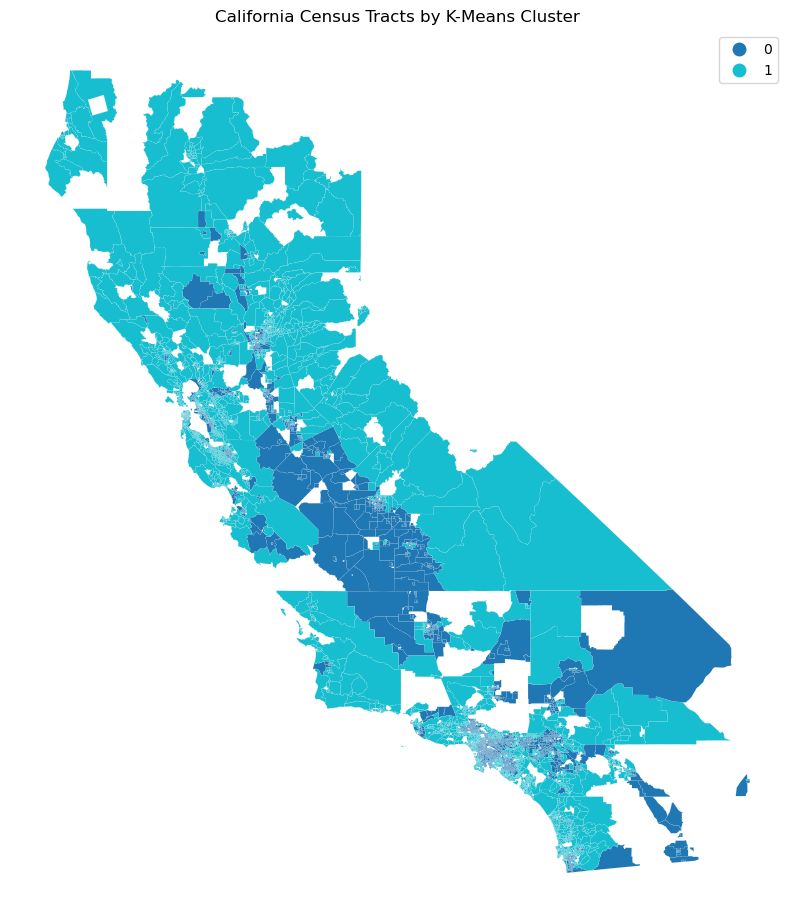

In [14]:
ax = gdf.plot(
    column="cluster_2",
    categorical=True,
    legend=True,
    figsize=(10, 12),
    linewidth=0.05,
    edgecolor="white"
)

ax.set_title("California Census Tracts by K-Means Cluster")
ax.set_axis_off()

plt.savefig("visualizations/kmeans_visualizations/cluster_map_2.png", dpi=300, bbox_inches="tight")
plt.show()

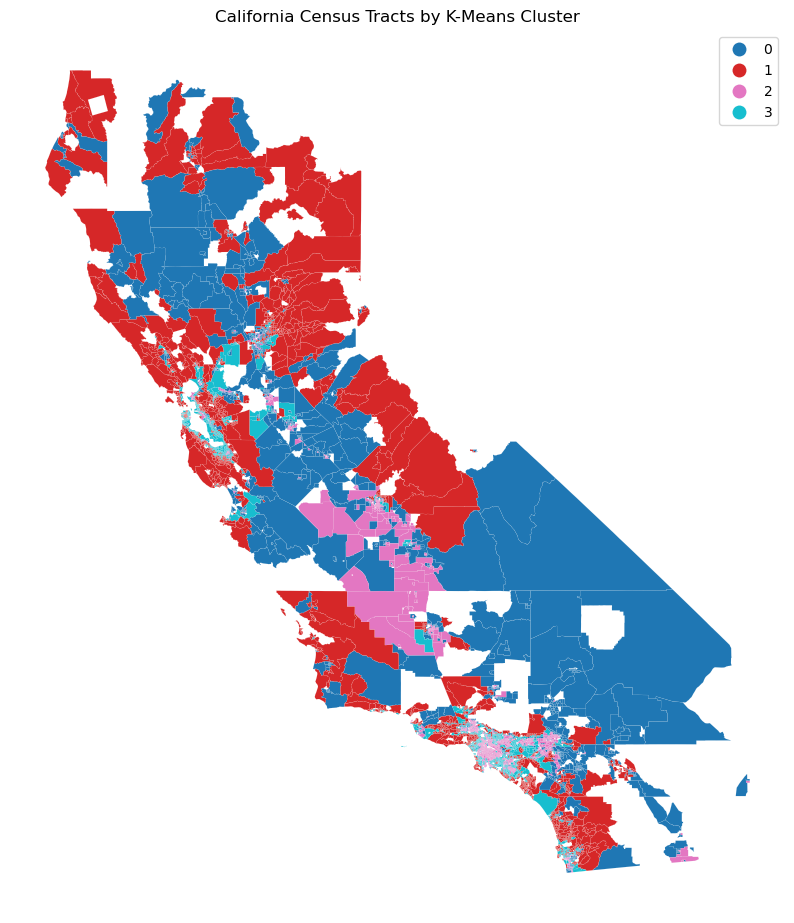

In [15]:
ax = gdf.plot(
    column="cluster_4",
    categorical=True,
    legend=True,
    figsize=(10, 12),
    linewidth=0.05,
    edgecolor="white"
)

ax.set_title("California Census Tracts by K-Means Cluster")
ax.set_axis_off()

plt.savefig("visualizations/kmeans_visualizations/cluster_map_4.png", dpi=300, bbox_inches="tight")
plt.show()